In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("data\\train.csv")
val_df = pd.read_csv("data\\validation.csv")

In [ ]:
vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])
X_train = vectorizer.transform(train_df['full_name'])
X_val = vectorizer.transform(val_df['full_name'])

y_train = train_df['label']
y_val = val_df['label']

In [ ]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)
predicted_y = rfc.predict(X_val)

In [ ]:
accuracy = accuracy_score(y_val, predicted_y) * 100

recall = recall_score(y_val, predicted_y) * 100

precision = precision_score(y_val, predicted_y) * 100

f1= f1_score(y_val, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_val, predicted_y))

Accuracy: 87.09382748270912
Recall: 85.07306889352819
Precision: 88.65923307043786
f1_score: 86.82913836729259

              precision    recall  f1-score   support

           0       0.86      0.89      0.87     19155
           1       0.89      0.85      0.87     19160

    accuracy                           0.87     38315
   macro avg       0.87      0.87      0.87     38315
weighted avg       0.87      0.87      0.87     38315



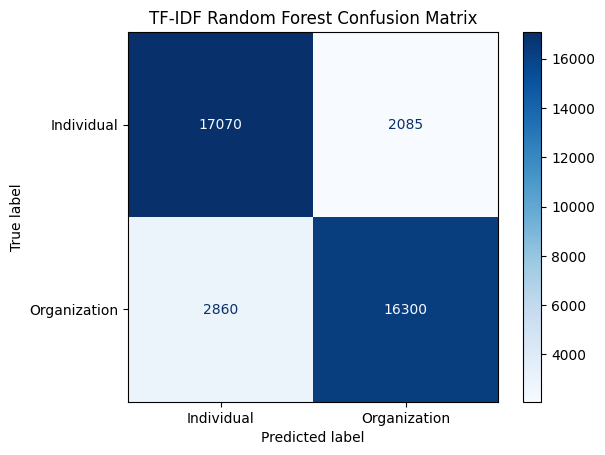

In [ ]:
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title('TF-IDF Validation Random Forest Confusion Matrix')
plt.savefig('TF-IDF Validation Random Forest Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [ ]:
test_df = pd.read_csv("data\\test.csv")
X_test = vectorizer.transform(test_df['full_name'])
y_test = test_df['label']

In [ ]:
predicted_y_test = rfc.predict(X_test)
print(classification_report(y_test, predicted_y_test))

In [ ]:
cm = confusion_matrix(y_test, predicted_y_test, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title('TF-IDF Test Random Forest Confusion Matrix')
plt.savefig('TF-IDF Test Random Forest Confusion Matrix.png', transparent=True, bbox_inches = 'tight')
plt.show()

In [201]:
misclassified = np.where(y_test != predicted_y)[0]
misclassified


array([    1,    17,    23, ..., 38304, 38306, 38307], shape=(4945,))

In [202]:
y_val_df = y_test.reset_index().copy()
y_val_df

,index,label
0,0,0
1,1,1
2,2,0
3,3,0
4,4,0
...,...,...
38310,38310,1
38311,38311,0
38312,38312,1
38313,38313,1


In [ ]:

inverse_names = vectorizer.inverse_transform(X_val)

inverse_names_clean = []
for i in misclassified:
	inverse_names_clean.append(" ".join(list(inverse_names[i])))

print(f"Number of misclassified samples: {len(misclassified)}")
ctr = -1
for i in misclassified:
	ctr+=1
	print(f"ctr: {ctr}")
	print(f"Index: {i}")
	print(f"Full Name: {inverse_names_clean[ctr]}")
	print(f"True Label: {y_val_df.iloc[i]['label']}, Predicted: {predicted_y[i]}")
	print("---")
# Organization = 0
# Individual = 1

IndexError: index 55991 is out of bounds for axis 0 with size 50669